In [13]:
# @markdown ## **Ejecutar esta celda para obtener librerías 📚(►)**
# @markdown
# @markdown Doble clic en mí y podrás ver mi código.
# =====================================================================================================================
# REGION: Congiguración de la consola
# =====================================================================================================================
from rich.console import Console
from rich.theme import Theme
from rich.progress import Progress
TemaAnalisisDatos = Theme({
    "info": "bold navy_blue on grey82",
    "url": "underline blue",
    "warning": "dark_orange",
    "danger": "bold red",
    "normalb": "bold black",
    "normal": "black"
}, inherit=False)
console = Console(theme=TemaAnalisisDatos)
# =====================================================================================================================
# REGION: Librerías
# =====================================================================================================================
with console.status("Cargando Librerías", spinner="clock"):
    import os
    import random as rnd
    import pandas as pd
    import time
    import logging
    import tqdm
    import rich
    import numpy as np
    import matplotlib.pyplot as plt
    import statistics as st
    import math as mt
    # from google.colab import drive
    import sys
    import datetime
    import time
    from tqdm import tqdm
    #import ace_tools as tools
    from collections import Counter
    inicio = time.time()
    import warnings
    # Ignorar todos los warnings
    warnings.filterwarnings("ignore")
# =====================================================================================================================
# REGION: Librerías
# =====================================================================================================================
console.print("Librerías cargadas satisfactoriamente", style="info")

Librerías cargadas satisfactoriamente

In [14]:
# @markdown ## **Ejecutar esta celda para las funciones iniciales 🚀(►)**
# @markdown
# @markdown Doble clic en mí y podrás ver mi código.
# =====================================================================================================================
# REGION: Funciones Útiles para Taller Proyecto Integrador
# NOTA: Las funciones fueron comentadas con GitHub Copilot
# =====================================================================================================================
def GenerarNombre(Nombres: list, Apellidos: list) -> str:
    """
    Genera un nombre completo seleccionando aleatoriamente un nombre y un apellido de las listas proporcionadas.

    Args:
        Nombres (list): Lista de nombres posibles.
        Apellidos (list): Lista de apellidos posibles.

    Returns:
        str: Un nombre completo en el formato 'Nombre Apellido'.
    """
    Nombre = rnd.choice(Nombres)
    Apellido = rnd.choice(Apellidos)
    return f'{Nombre} {Apellido}'

def GenerarEdad() -> int:
    """
    Genera una edad aleatoria basada en probabilidades predefinidas.

    Returns:
        int: Una edad aleatoria en uno de los siguientes rangos:
             - 16 a 25 años (50% de probabilidad)
             - 26 a 33 años (25% de probabilidad)
             - 34 a 40 años (15% de probabilidad)
             - 41 a 105 años (10% de probabilidad)
    """
    r = rnd.random()
    if r < 0.5:
        return rnd.randint(16, 25)
    elif r < 0.75:
        return rnd.randint(26, 33)
    elif r < 0.9:
        return rnd.randint(34, 40)
    else:
        return rnd.randint(41, 105)

def GenerarHoraAtencion_Lista() -> list:
    """
    Genera una lista de posibles horas de atención en intervalos de 20 minutos.

    Returns:
        list: Una lista de listas, donde cada sublista contiene una hora y un minuto en el formato [hora, minuto].
              Las horas van de 7 a 18 (inclusive) y los minutos pueden ser 0, 20 o 40.
    """
    horas = [x for x in range(7,19)]
    minutos = [0,20,40]
    citas_list = []
    for hora in horas:
        for minuto in minutos:
            citas_list.append([hora,minuto])
    return citas_list

def GenerarHoraAtencion_str() -> list:
    """
    Genera una lista de posibles horas de atención en formato de cadena.

    Returns:
        list: Una lista de cadenas, donde cada cadena representa una hora de atención en el formato "HH:MM".
              Las horas van de 7 a 18 (inclusive) y los minutos pueden ser 0, 20 o 40.
    """
    horas = [x for x in range(7,19)]
    minutos = [0,20,40]
    citas_list = []
    citas_str = []
    for hora in horas:
        for minuto in minutos:
            citas_list.append([hora,minuto])
    for hora, minuto in citas_list:
        citas_str.append(datetime.time(hora, minuto).strftime("%H:%M"))
    return citas_str

def SiguienteSemana():
    """
    Calcula las fechas de la próxima semana (de lunes a domingo) a partir de la fecha actual.

    Returns:
        list: Una lista de cadenas, donde cada cadena representa una fecha de la próxima semana en el formato "YYYY-MM-DD".
    """
    hoy = datetime.date.today()
    dia_semana = hoy.weekday()
    diferencia = (0 - dia_semana) % 7
    # Sumamos la diferencia a la fecha actual
    semana = []
    semana.append(str(hoy + datetime.timedelta(days=diferencia)))
    for i in range(1,7):
        semana.append(str(hoy + datetime.timedelta(days=diferencia+i)))
    return semana

import random

# Listas de médicos y tipos de cita (Los he creado para tener algo chévere)
medicos = ["Dr. Pérez", "Dr. García", "Dra. Martínez", "Dr. López"]
tipos_cita = ["Consulta General", "Urgencias", "Control Médico", "Examen"]

# Función para generar una cédula aleatoria
def GenerarCedula():
    return random.randint(1000000000, 1200000000)  # Cédula de 10 dígitos

# Función para asignar médico y tipo de cita aleatorios
def AsignarMedicoYTipo():
    medico = random.choice(medicos)
    tipo_cita = random.choice(tipos_cita)
    return medico, tipo_cita

In [15]:
# @markdown ## **Ejecutar esta celda para crear la base de datos 💼(►)**
# @markdown
# @markdown Doble clic en mí y podrás ver mi código.
# =====================================================================================================================
# REGION: Log
# =====================================================================================================================
console.print(f'{"Inicio del proceso"}', style="info")
console.print(f'\t{"Log"}', style="danger")
inicio = time.time() #Inicio contador de ejecucion
hoy = datetime.date.today().strftime('%Y%m%d') #Captura de fecha de ejecucion
nombre_archivo_log = f"log_{hoy}.log" # Inicializacion del log
#Configuracion de almacenamiento y niveles del log
logging.basicConfig(filename=nombre_archivo_log, level=logging.INFO,
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
#Primer registro del log
logging.info(f"Iniciando el proceso del log __{hoy}__ ")
# =====================================================================================================================
# REGION: Ubicacion y registro de archivos
# =====================================================================================================================
#Creamos el directorio (carpeta) en donde se crearan los archivos
console.print(f'\t{"Ubicacion y registro de archivos"}', style="danger")
DirectorioActual = os.getcwd() #Directorio actual de trabajo
textemp = f'El directorio actual de trabajo es: \n\t--> {DirectorioActual}, \nEsta carpeta contendrá los archivos del trabajo final'
logging.info(textemp) #Registro del directorio actual
#Creamos una carpeta donde almacenamos los resultados
CarpetaNueva = "CarpetaArchivosTrabajoFinal"
os.makedirs(CarpetaNueva, exist_ok=True) #Creamos la carpeta si no existe
logging.info("Se crea el directorio {}".format(CarpetaNueva)) #Registro de la creacion de la carpeta
# Nombre de la carpeta donde se crearán los archivos
carpeta = os.path.join(DirectorioActual, "CarpetaArchivosTrabajoFinal") #Ruta de la carpeta
logging.info("La ruta de trabajo será {}".format(carpeta)) #Registro de la ruta de trabajo
#Usamos los datos de GitHub con nombres y apellidos para leerlos.
RutaNombres = r'https://raw.githubusercontent.com/juliancastillo-udea/AlDiSi/main/Data/NombresArgentina.csv'
RutaApellidos = r'https://raw.githubusercontent.com/juliancastillo-udea/AlDiSi/main/Data/ApellidosArgentina.csv'
# =====================================================================================================================
# REGION: Creando datos genericos
# =====================================================================================================================
console.print(f'\t{"Creando datos genericos"}', style="danger")
logging.info("Cargando CSV con nombres")
dfNombres = pd.read_csv(RutaNombres, encoding='ISO-8859-1')
Nombres = dfNombres['name'].tolist()
logging.info("Reemplazando nombres y detalles del documento")
for i in tqdm(range(len(Nombres)), '\tProcesando nombres'):
    if ' ' in Nombres[i]:
        Nombres[i]=Nombres[i].replace(' ', '_')
logging.info("Cargando CSV con apellidos")
dfApellidos = pd.read_csv(RutaApellidos, encoding='ISO-8859-1')
Apellidos = dfApellidos['lastname'].tolist()
logging.info("Reemplazando apellidos y detalles del documento")
for i in tqdm(range(len(Apellidos)), '\tProcesando apellidos'):
    if ' ' in Apellidos[i]:
        Apellidos[i]=Apellidos[i].replace(' ', '_')
logging.info("Finalizado proceso de gestion de nombres y apellidos")
# endregion Gestion de archivos y ubicaciones
logging.info("Creando secuencia de citas")
horarioatencion = GenerarHoraAtencion_str()
semana = SiguienteSemana()
citas = []
for dia in semana:
    for cita in horarioatencion:
        citas.append(dia+'|'+cita)
# =====================================================================================================================
# REGION: Creacion del dataframe
# =====================================================================================================================
console.print(f'\t{"Creación del dataframe"}', style="danger")
logging.info("Creando DataFrame con datos de citas y personas")
df = pd.DataFrame(columns=['Nombre', 'Edad', 'Fecha', 'CitaAtencion', 'Cédula', 'Médico', 'Tipo de Cita'])

for cita in citas:
    nombre = GenerarNombre(Nombres, Apellidos).upper()
    edad = GenerarEdad()
    fecha = datetime.date.today().strftime('%Y-%m-%d')
    atencion = cita
    cedula = GenerarCedula()
    medico, tipo_cita = AsignarMedicoYTipo()  # Asignamos un médico y tipo de cita aleatorios
    vector = [nombre, edad, fecha, atencion, cedula, medico, tipo_cita]
    df.loc[len(df)] = vector

fin = time.time()
delta = fin - inicio
minutos, segundos = divmod(delta, 60)
console.print(f'\t{"Fin dataframe"}', style="danger")
console.print(f'\tTiempo de ejecución: {int(minutos)} minutos y {segundos:.2f} segundos', style="url")

console.print(f'\tTiempo de ejecucion: {int(minutos)} minutos y {segundos:.2f} segundos', style="url")
logging.info("Exportar DataFrame a Excel y CSV")
df.to_excel(os.path.join(carpeta,'Citas.xlsx'))
df.to_csv(os.path.join(carpeta,'Citas.csv'))
logging.info("Finalizado")
console.print(f'{"Fin del proceso"}', style="info")
# =====================================================================================================================
# REGION: Fin
# =====================================================================================================================

Inicio del proceso

        Log

        Ubicacion y registro de archivos

        Creando datos genericos

	Procesando apellidos: 100%|██████████| 321516/321516 [00:00<00:00, 1278891.26it/s]


        Creación del dataframe

        Fin dataframe

        Tiempo de ejecución: 0 minutos y 1.59 segundos

        Tiempo de ejecucion: 0 minutos y 1.59 segundos

Fin del proceso

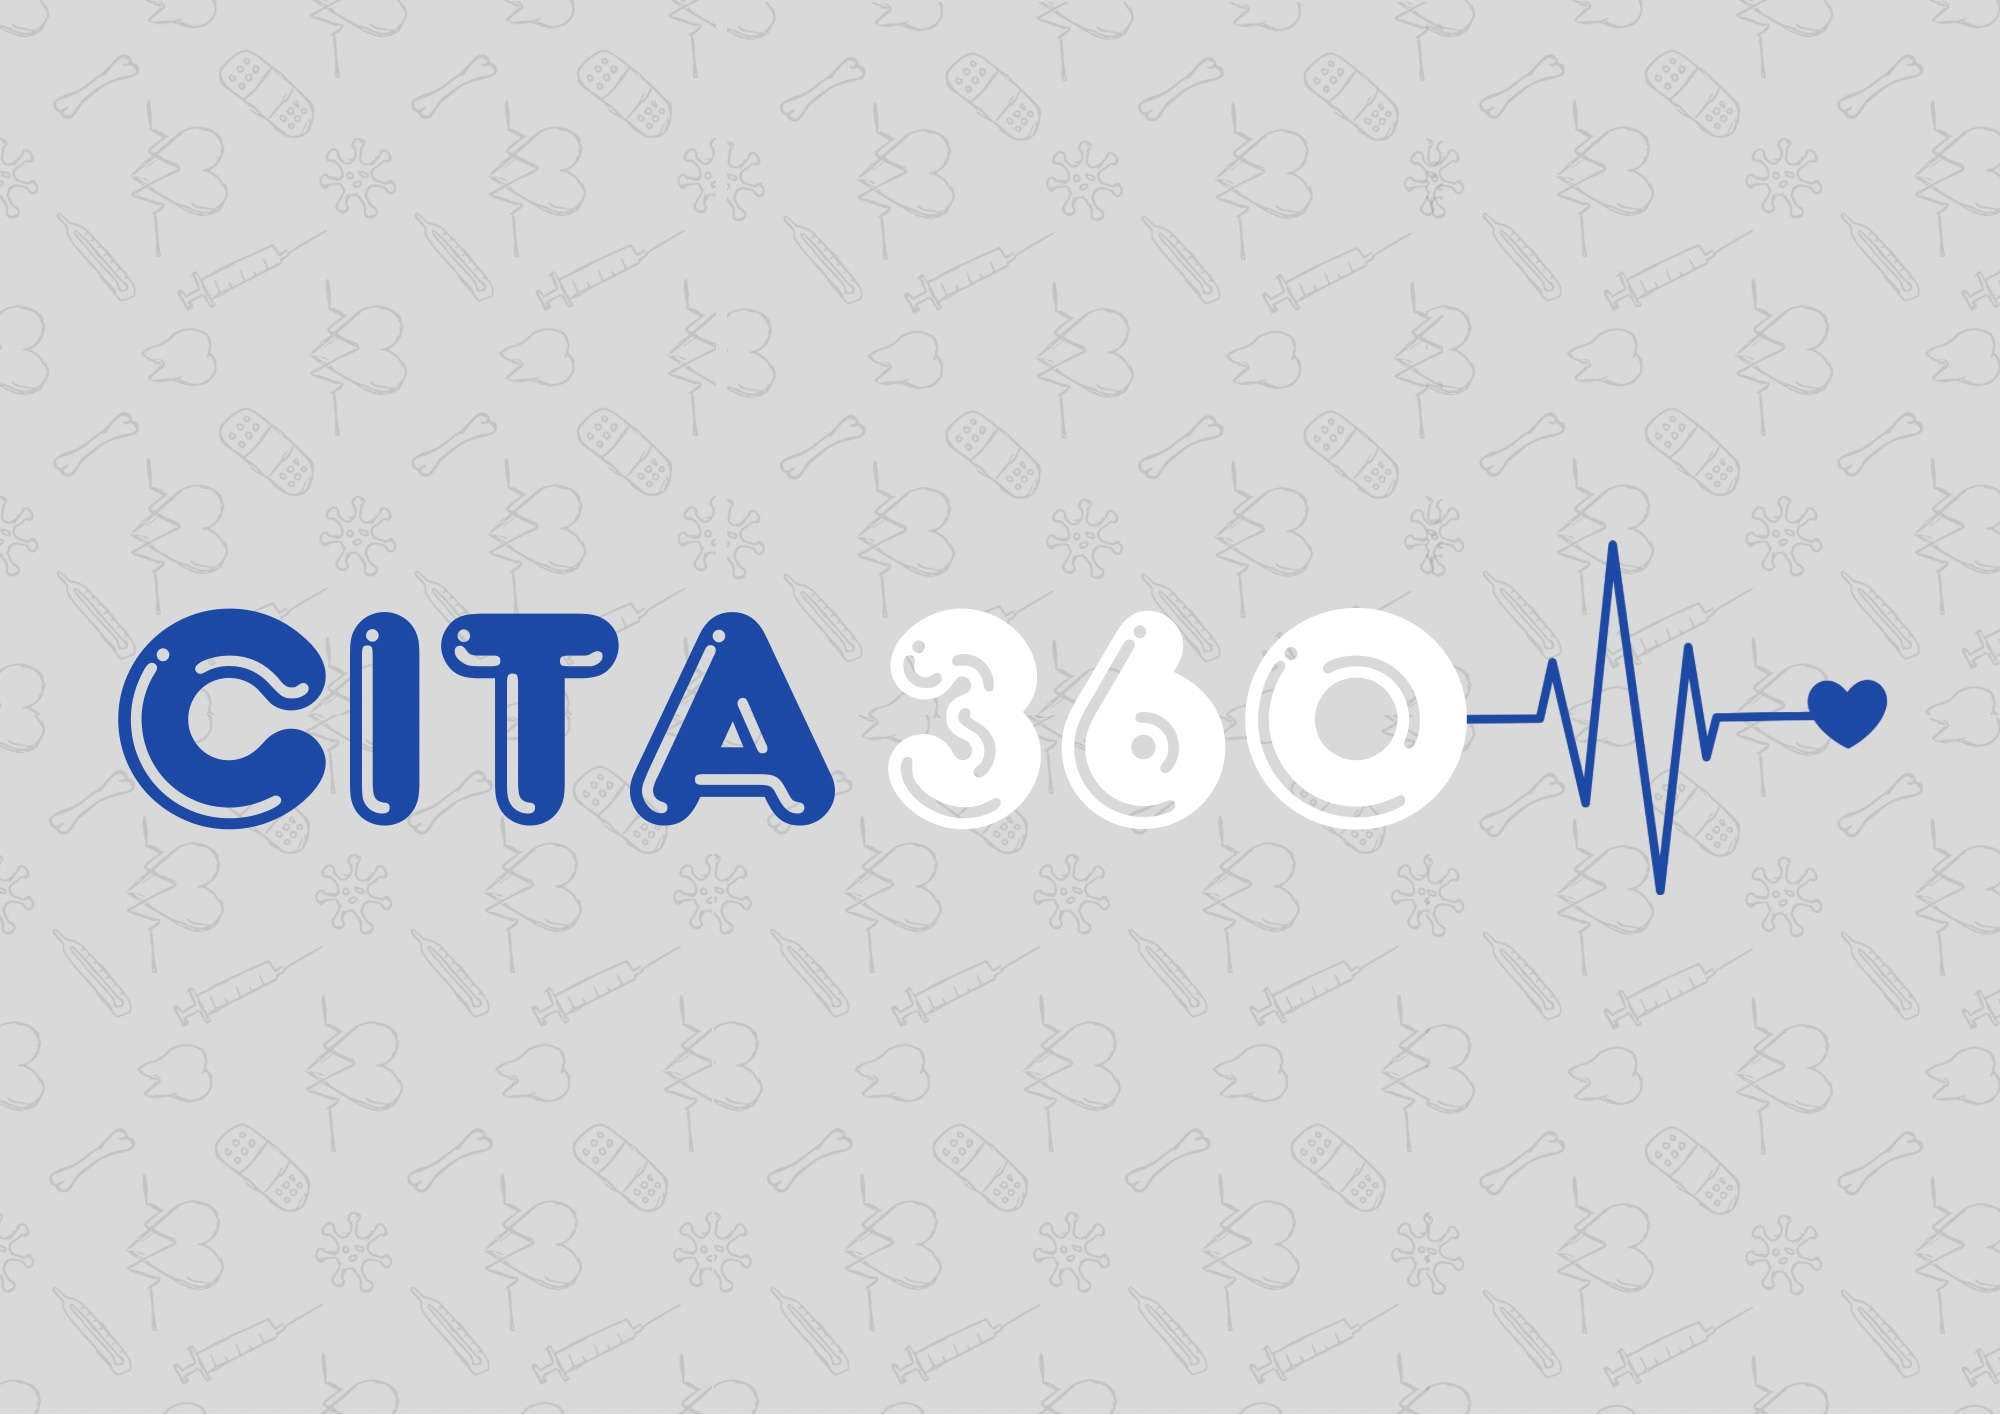

In [16]:
# @markdown ## **Bienvenido a CITA360. Por favor ejecuta para gestionar tus citas en la EPS Pailasalud ❤️(►)**
# @markdown
# @markdown Doble clic en mí y podrás ver mi código.
# =====================================================================================================================
# REGION: PROGRAMA CREADO
# =====================================================================================================================
from datetime import datetime, timedelta

# Función para confirmar cita
def confirmar_cita(df, cedula_usuario):
    cita_usuario = df[df["Cédula"].astype(str) == cedula_usuario]
    if not cita_usuario.empty:
        # Con esto agrego el estado confirmado
        df.loc[df["Cédula"].astype(str) == cedula_usuario, 'Estado'] = 'Confirmada'
        print(f"\nTu cita ha sido confirmada para el {cita_usuario.iloc[0]['CitaAtencion']}. ¡Gracias por usar CITA360!")
    else:
        print("No se encontró ninguna cita asociada a esta cédula.")
    return df

# Función para cancelar cita
def cancelar_cita(df, cedula_usuario):
    cita_usuario = df[df["Cédula"].astype(str) == cedula_usuario]
    if not cita_usuario.empty:
        # Con esto agrego el estado cancelado
        df.loc[df["Cédula"].astype(str) == cedula_usuario, 'Estado'] = 'Cancelada'
        print(f"\nTu cita ha sido cancelada. ¡Gracias por usar CITA360!")
    else:
        print("No se encontró ninguna cita asociada a esta cédula.")
    return df

# Función para modificar cita
def modificar_cita(df, cedula_usuario):
    cita_usuario = df[df["Cédula"].astype(str) == cedula_usuario]
    if not cita_usuario.empty:
        # Con esto separo las fecha y la hora para evitar errores de lectura
        cita_original_str = cita_usuario.iloc[0]["CitaAtencion"]
        fecha_original, hora = cita_original_str.split('|')  # Separo fecha y hora
        fecha_original = datetime.strptime(fecha_original, '%Y-%m-%d')  # convierto la fecha a datetime

        # Imprimo la fecha original
        print(f"\nTu cita inicial es el {fecha_original.strftime('%Y-%m-%d')} a las {hora}.")

        # Creo opciones futuras de citas (15 días posteriores manteniendo la hora)
        opciones_futuras = [(fecha_original + timedelta(days=i)).strftime('%Y-%m-%d') + '|' + hora for i in range(1, 16)]

        # muestro las opciones futuras
        print("Elige una nueva fecha entre los próximos 15 días:")
        for i, opcion in enumerate(opciones_futuras, start=1):
            print(f"{i}. {opcion}")

        opcion_elegida = input("\nIngresa el número de la fecha que prefieres: ")
        if opcion_elegida.isdigit() and 1 <= int(opcion_elegida) <= 15:
            nueva_fecha = opciones_futuras[int(opcion_elegida) - 1]
            # Con esto actualizado el estado a modificado y agrego la fecha
            df.loc[df["Cédula"].astype(str) == cedula_usuario, 'Estado'] = f'Modificada para {nueva_fecha}'
            print(f"\nTu cita fue modificada para el {nueva_fecha}. ¡Gracias por usar CITA360!")
        else:
            print("Opción no válida. No se ha realizado ningún cambio.")
    else:
        print("No se encontró ninguna cita asociada a esta cédula.")

    return df

# Función para generar reportes de citas a administrador
def generar_reportes(df):
    # Filtro las citas por estado
    citas_confirmadas = df[df['Estado'] == 'Confirmada']
    citas_canceladas = df[df['Estado'] == 'Cancelada']
    citas_modificadas = df[df['Estado'].str.contains('Modificada', na=False)]

    # Guardo cada dataframe en un archivo CSV
    citas_confirmadas.to_csv('citas_confirmadas.csv', index=False)
    citas_canceladas.to_csv('citas_canceladas.csv', index=False)
    citas_modificadas.to_csv('citas_modificadas.csv', index=False)

    print("\nLos reportes han sido generados y guardados como archivos CSV.")
    print("Puedes descargar los archivos desde la carpeta del programa.")
    input("Presiona Enter para continuar.")

# Menús principales
menu_principal = ['Bienvenido a CITA360, software de la EPS Pailasalud',
                  'Por favor selecciona una opción:',
                  '1. Administrador',
                  '2. Usuario',
                  '3. Salir']

menu_admin = ['Bienvenido administrador',
              '1. Ver reportes',
              '2. Crear usuarios',
              '3. Salir']

menu_usuario = ['Bienvenido usuario',
                '1. Confirmar cita',
                '2. Cancelar cita',
                '3. Modificar cita',
                '4. Consultar cita',
                '5. Salir']

# Usuario y contraseña del administrador
usuarios = {"admin": "admin123"}  # Usuario inicial por defecto
citas = {}

def imprimir_menu(menu):
    os.system('cls')
    for opcion in menu:
        print(opcion)  # imprimo cada opción en el menú


# Programa
while True:
    imprimir_menu(menu_principal)
    opcion = input("Ingresa una opción del menú por favor: ")

    if opcion == '1':  # Administrador
        usuario = input('Ingrese su usuario: ')
        contrasenia = input('Ingrese su contraseña: ')

        if usuarios.get(usuario) == contrasenia:
            while True:
                imprimir_menu(menu_admin)
                opcion_admin = input("Ingresa una opción por favor: ")

                if opcion_admin == '1':  # Ver reportes
                    print("Generando reportes...")
                    generar_reportes(df)  # Con esto llamo a la función que genera los reportes
                    break

                elif opcion_admin == '2':  # Crear administradores nuevos
                    nuevo_usuario = input("Ingresa el nombre del nuevo usuario: ")
                    nueva_contrasena = input("Ingresa la contraseña para el usuario: ")
                    usuarios[nuevo_usuario] = nueva_contrasena
                    print(f"Usuario {nuevo_usuario} registrado correctamente.")
                    input("Presiona Enter para continuar.")
                    break

                elif opcion_admin == '3':  # Salir
                    print("Gracias por usar CITA360, que tenga un excelente día.")
                    break

                else:
                    print("Opción no válida.")
        else:
            print("Usuario o contraseña incorrectos.")

    elif opcion == '2':  # Usuario
        while True:
            imprimir_menu(menu_usuario)
            opcion_usuario = input("Ingresa una opción por favor: ")

            if opcion_usuario == '1':  # Confirmar cita
                cedula_usuario = input("Ingresa tu cédula para confirmar la cita: ")
                cedula_usuario = str(cedula_usuario)
                df = confirmar_cita(df, cedula_usuario)
                break

            elif opcion_usuario == '2':  # Cancelar cita
                cedula_usuario = input("Ingresa tu cédula para cancelar la cita: ")
                cedula_usuario = str(cedula_usuario)
                df = cancelar_cita(df, cedula_usuario)
                break

            elif opcion_usuario == '3':  # Modificar cita
                cedula_usuario = input("Ingresa tu cédula para modificar la cita: ")
                cedula_usuario = str(cedula_usuario)
                df = modificar_cita(df, cedula_usuario)
                break

            elif opcion_usuario == '4':  # Consultar cita
                cedula = input("Ingresa tu cédula para consultar la cita: ")
                cedula = str(cedula)
                cita_usuario = df[df["Cédula"].astype(str) == cedula]

                if not cita_usuario.empty:
                    print(f"\nCédula: {cedula}") # le imprime su identificación
                    print(f"Nombre: {cita_usuario.iloc[0]['Nombre']}") #le imprime su nombre
                    print(f"Fecha de atención: {cita_usuario.iloc[0]['CitaAtencion']}") #le imprime la fecha de atención
                    print(f"Médico: {cita_usuario.iloc[0]['Médico']}") # le imprime el médico que le atiende
                    print(f"Tipo de cita: {cita_usuario.iloc[0]['Tipo de Cita']}") # le imprime el tipo de cita
                else:
                    print("No se encontró ninguna cita asociada a esta cédula.")
                input("Presiona Enter para continuar.")

    elif opcion == '3':  # Salir
        print("Gracias por usar CITA360 de la EPS Pailasalud. ¡Hasta luego!")
        break

    else:
        print("Opción no válida. Inténtalo de nuevo.")




Bienvenido a CITA360, software de la EPS Pailasalud
Por favor selecciona una opción:
1. Administrador
2. Usuario
3. Salir
Ingresa una opción del menú por favor: 2
Bienvenido usuario
1. Confirmar cita
2. Cancelar cita
3. Modificar cita
4. Consultar cita
5. Salir
Ingresa una opción por favor: 4
Ingresa tu cédula para consultar la cita: 1157551087

Cédula: 1157551087
Nombre: JOSEBA_JOKIN SCHAAP
Fecha de atención: 2024-12-09|08:40
Médico: Dra. Martínez
Tipo de cita: Control Médico
Presiona Enter para continuar.
Bienvenido usuario
1. Confirmar cita
2. Cancelar cita
3. Modificar cita
4. Consultar cita
5. Salir
Ingresa una opción por favor: 2
Ingresa tu cédula para cancelar la cita: 1157551087

Tu cita ha sido cancelada. ¡Gracias por usar CITA360!
Bienvenido a CITA360, software de la EPS Pailasalud
Por favor selecciona una opción:
1. Administrador
2. Usuario
3. Salir
Ingresa una opción del menú por favor: 3
Gracias por usar CITA360 de la EPS Pailasalud. ¡Hasta luego!
